# Support Vector Machines
ML LAB 5

Yasir Ahmad

In [110]:

import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
%pip install mlxtend
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.inspection import DecisionBoundaryDisplay



[notice] A new release of pip is available: 23.3.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [111]:
import numpy as np # type: ignore
import tensorflow as tf # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense # type: ignore
from sklearn.datasets import make_classification, make_moons # type: ignore
import matplotlib.pyplot as plt # type: ignore

# Function to generate linear and non-linear datasets
def generate_datasets():
    # Linear Dataset
    X_linear, y_linear = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, 
                                             n_clusters_per_class=1, n_classes=2, random_state=42)
    
    # Non-linear Dataset (moons)
    X_nonlinear, y_nonlinear = make_moons(n_samples=500, noise=0.2, random_state=42)
    
    return (X_linear, y_linear), (X_nonlinear, y_nonlinear)

# Plotting function to visualize datasets
def plot_datasets(X, y, title):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
    plt.title(title)
    plt.show()


In [112]:
(X_linear, y_linear), (X_nonlinear, y_nonlinear) = generate_datasets()

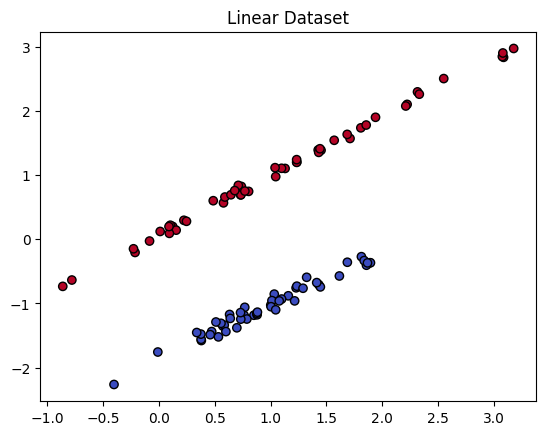

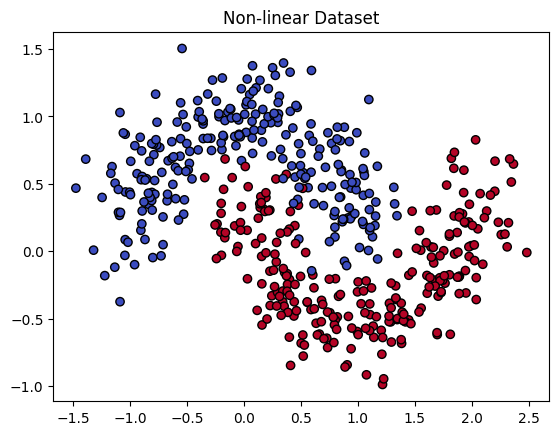

In [113]:
# Plot datasets
plot_datasets(X_linear, y_linear, 'Linear Dataset')
plot_datasets(X_nonlinear, y_nonlinear, 'Non-linear Dataset')

### Linear Dataset


In [114]:
(X,y) = (X_linear, y_linear)

y = np.where(y == 0, -1, 1)  # Convert labels to {-1, 1}


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [115]:
X[:5]

array([[ 1.22831184, -0.75717844],
       [ 0.69840909, -1.38029525],
       [ 2.54881729,  2.50225822],
       [ 0.57357881, -1.35297943],
       [ 0.58590018, -1.33745666]])

In [116]:
y[:5]

array([-1, -1,  1, -1, -1])

#### Without Using Kernel (Custom Linear SVC)

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# LinearSVC class from the previous code
class LinearSVC:
    def __init__(self, learning_rate=0.001, lambda_param=0.1, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1).astype(np.float64)  # Convert to float64

        # Initialize weights and bias
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                margin = y_[idx] * (np.dot(x_i, self.w) - self.b)
                if margin < 1:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - y_[idx] * x_i)
                    self.b -= self.lr * y_[idx]
                else:
                    self.w -= self.lr * 2 * self.lambda_param * self.w

    def predict(self, X):
        linear_output = np.dot(X, self.w) - self.b
        return np.sign(linear_output)

In [118]:
y = np.where(y == 0, -1, 1)  # Convert labels to {-1, 1}

# Train the LinearSVC model
svc = LinearSVC(learning_rate=0.01, lambda_param=0.01, n_iters=1000)
svc.fit(X_train, y_train)

In [119]:
y_pred = svc.predict(X_test)

accuracy_linear_SVC = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_linear_SVC)


Accuracy: 1.0


In [120]:
y_pred, y_test

(array([-1., -1.,  1.,  1., -1., -1., -1.,  1., -1., -1.,  1., -1., -1.,
        -1.,  1., -1., -1.,  1.,  1., -1.]),
 array([-1, -1,  1,  1, -1, -1, -1,  1, -1, -1,  1, -1, -1, -1,  1, -1, -1,
         1,  1, -1]))

In [121]:
import matplotlib.pyplot as plt
import numpy as np

def plot_linear_svm(X, y, svm_model):
    """
    Plot the decision boundary of the linear SVM model

    Parameters:
    - X: input features (n_samples, n_features)
    - y: target labels (n_samples)
    - svm_model: trained linear SVM model
    """
    # Create a meshgrid of points to evaluate the model
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    # Flatten the grid to pass into the model for predictions
    Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Reshape the predictions back to the meshgrid shape
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')  # using coolwarm colormap for decision boundary

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis')  # using viridis colormap for data points
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Linear SVM Decision Boundary')
    plt.show()

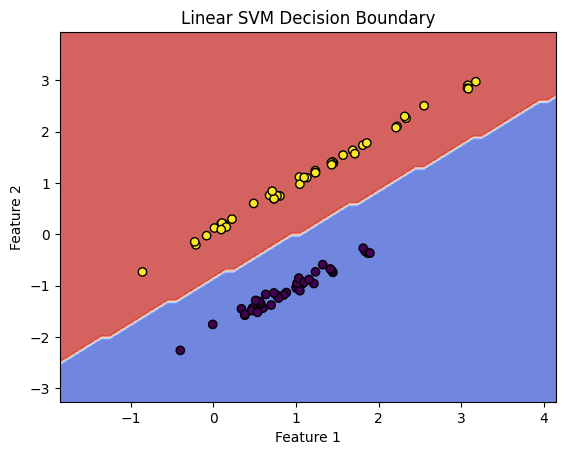

In [122]:
plot_linear_svm(X_train, y_train, svc)

#### With Linear Kernel

In [123]:
model = svm.SVC(kernel='linear',max_iter = 100)
model.fit(X_train, y_train)

SVC(kernel='linear', max_iter=100)

In [124]:
y_pred = model.predict(X_test)
accuracy_linear_kernel = accuracy_score(y_test, y_pred)
print("Accuracy on test data:", accuracy_linear_kernel)

Accuracy on test data: 1.0


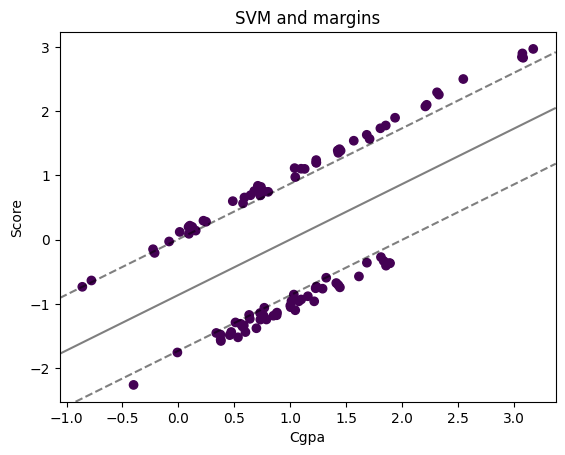

In [125]:
# Plot the decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                     np.linspace(ylim[0], ylim[1], 100))
xy = np.c_[xx.ravel(), yy.ravel()]
Z = model.decision_function(xy).reshape(xx.shape)

plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
            linestyles=['--', '-', '--'])
plt.xlabel('Cgpa')
plt.ylabel('Score')
plt.title('SVM and margins')
plt.show()

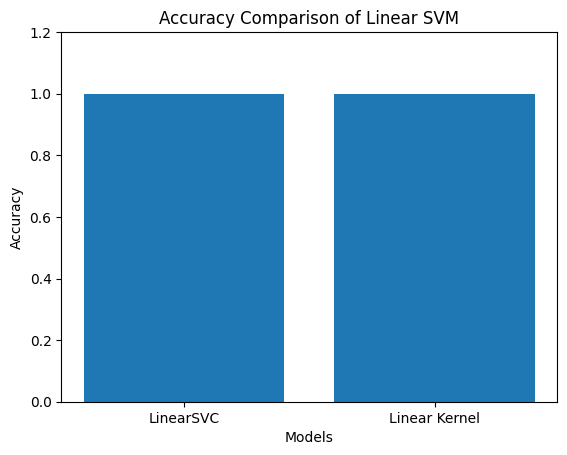

In [126]:
import matplotlib.pyplot as plt

# Accuracies
accuracies = [accuracy_linear_SVC, accuracy_linear_kernel]
models = ['LinearSVC', 'Linear Kernel']

# Bar graph
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Linear SVM')
plt.ylim(0, 1.2)  # Set y-axis limits to 0-1 for accuracy
plt.show()


### Non Linear Data

In [127]:
X,y = X_nonlinear, y_nonlinear

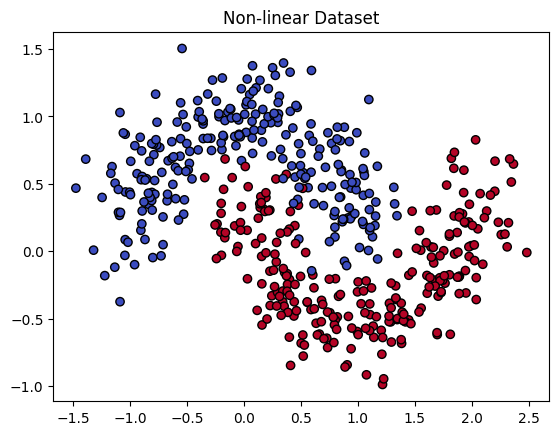

In [128]:
plot_datasets(X, y, 'Non-linear Dataset')

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Non linear SVM without Kernel

In [130]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

def nonlinear_svm(X, y, degree=2, C=1.0):
    """
    Non-linear SVM without kernel using polynomial expansion

    Parameters:
    - X: input features (n_samples, n_features)
    - y: target labels (n_samples)
    - degree: degree of polynomial expansion (default=2)
    - C: regularization parameter (default=1.0)

    Returns:
    - svm_model: trained SVM model
    """
    # Create polynomial features
    poly_features = PolynomialFeatures(degree=degree)
    X_poly = poly_features.fit_transform(X)

    # Train a logistic regression model on the polynomial features
    svm_model = LogisticRegression(C=C, penalty='l2')
    svm_model.fit(X_poly, y)

    return svm_model

In [131]:
import matplotlib.pyplot as plt
import numpy as np

def plot_nonlinear_svm(X, y, svm_model, degree=2, C=1.0):
    """
    Plot the decision boundary of the non-linear SVM model

    Parameters:
    - X: input features (n_samples, n_features)
    - y: target labels (n_samples)
    - svm_model: trained SVM model
    - degree: degree of polynomial expansion (default=2)
    - C: regularization parameter (default=1.0)
    """
    # Create a meshgrid of points to evaluate the model
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    # Create polynomial features for the meshgrid points
    poly_features = PolynomialFeatures(degree=degree)
    X_poly_mesh = poly_features.fit_transform(np.c_[xx.ravel(), yy.ravel()])

    # Evaluate the model on the meshgrid points
    Z = svm_model.predict(X_poly_mesh)

    # Reshape the predicted values to match the meshgrid shape
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')  # changed to coolwarm colormap

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.5, cmap='viridis')  # changed to viridis colormap
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Non-linear SVM Decision Boundary (degree={})'.format(degree))
    plt.show()

In [132]:
# Train a non-linear SVM model using polynomial expansion
svm_model = nonlinear_svm(X_train, y_train, degree=2, C=10.0)

# Make predictions on the testing set
y_pred = svm_model.predict(PolynomialFeatures(degree=2).fit_transform(X_test))

# Evaluate the model
accuracy_nonl = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy_nonl)

Accuracy: 0.86


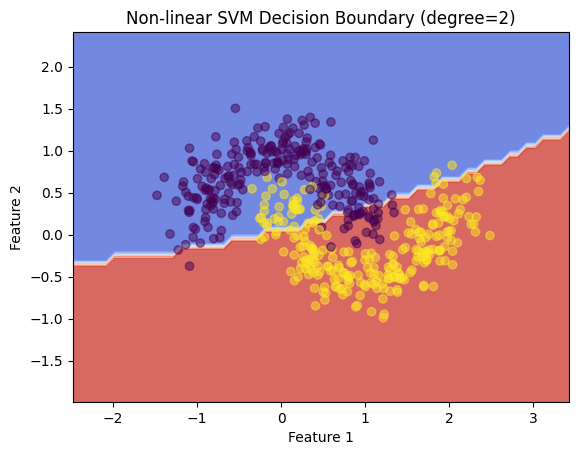

In [133]:
plot_nonlinear_svm(X, y, svm_model, degree=2, C=10.0)

####  Polynomial **Kernel**

In [134]:
# Train an SVM model
model = svm.SVC(kernel='poly',max_iter = 1000,C = 100.0)
model.fit(X_train, y_train)

c:\Users\YasirAhmd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=100.0, kernel='poly', max_iter=1000)

In [135]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using accuracy score
accuracy_non_linear_P = accuracy_score(y_test, y_pred)
print("Accuracy on test data:", accuracy_non_linear_P)

Accuracy on test data: 0.7


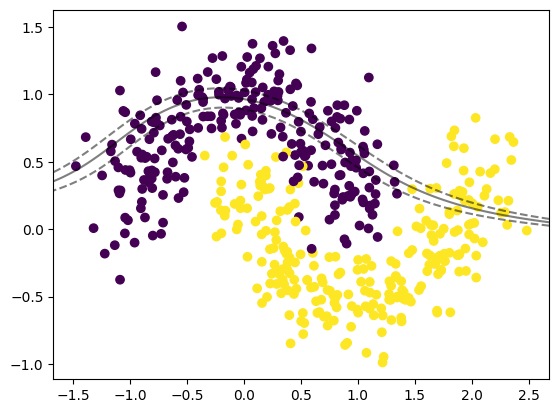

In [136]:
# Plot the decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                     np.linspace(ylim[0], ylim[1], 100))
xy = np.c_[xx.ravel(), yy.ravel()]
Z = model.decision_function(xy).reshape(xx.shape)

plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
            linestyles=['--', '-', '--'])
plt.show()

#### Polynomial Kernel (degree 6)

In [137]:
# Train an SVM model
model = svm.SVC(kernel='poly',max_iter = 5000,C = 100.0,degree=6)
model.fit(X_train, y_train)

c:\Users\YasirAhmd\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(C=100.0, degree=6, kernel='poly', max_iter=5000)

In [138]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using accuracy score
accuracy_non_linear_P6 = accuracy_score(y_test, y_pred)
print("Accuracy on test data:", accuracy_non_linear_P6)

Accuracy on test data: 0.83


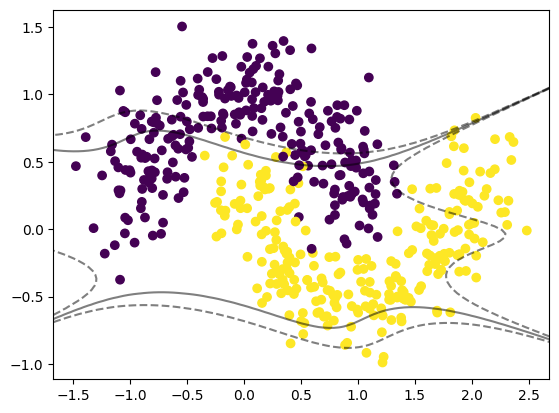

In [139]:
# Plot the decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                     np.linspace(ylim[0], ylim[1], 100))
xy = np.c_[xx.ravel(), yy.ravel()]
Z = model.decision_function(xy).reshape(xx.shape)

plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
            linestyles=['--', '-', '--'])
plt.show()

####  **Sigmoid** Kernel

In [140]:
# Train an SVM model
model = svm.SVC(kernel='sigmoid',max_iter = 10000)
model.fit(X_train, y_train)

SVC(kernel='sigmoid', max_iter=10000)

In [141]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using accuracy score
accuracy_non_linear_s = accuracy_score(y_test, y_pred)
print("Accuracy on test data:", accuracy_non_linear_s)

Accuracy on test data: 0.66


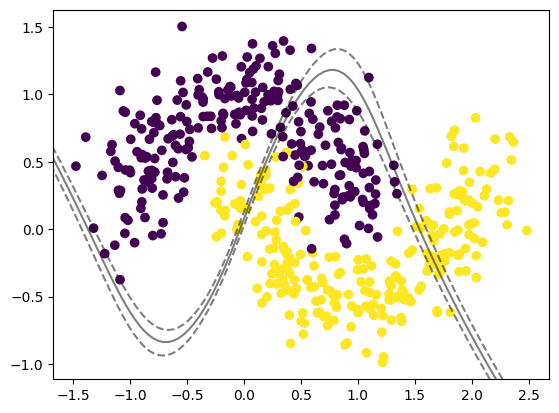

In [142]:
# Plot the decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                     np.linspace(ylim[0], ylim[1], 100))
xy = np.c_[xx.ravel(), yy.ravel()]
Z = model.decision_function(xy).reshape(xx.shape)

plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
            linestyles=['--', '-', '--'])
plt.show()

#### Gaussian Kernel Radial Basis Function (RBF)

In [143]:
# Train an SVM model
model = svm.SVC(kernel='rbf',max_iter = 10000)
model.fit(X_train, y_train)

SVC(max_iter=10000)

In [144]:
# Make predictions on the test set
y1_pred = model.predict(X_test)

# Evaluate the model using accuracy score
accuracy_non_linear_rbf = accuracy_score(y_test, y1_pred)
print("Accuracy on test data:", accuracy_non_linear_rbf)

Accuracy on test data: 0.96


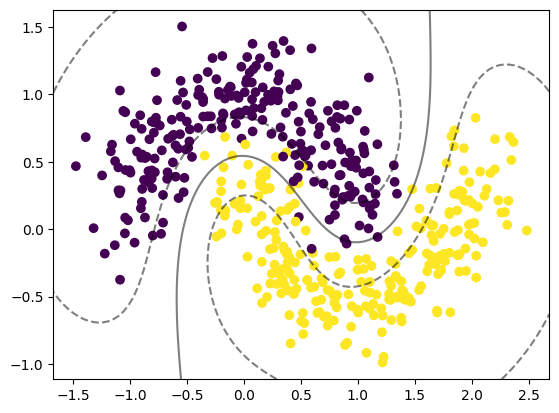

In [145]:
# Plot the decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100),
                     np.linspace(ylim[0], ylim[1], 100))
xy = np.c_[xx.ravel(), yy.ravel()]
Z = model.decision_function(xy).reshape(xx.shape)

plt.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
            linestyles=['--', '-', '--'])
plt.show()

#### Gaussian Kernel

In [146]:
def gaussian_kernel(X, Y, sigma=1.0):
    dists = euclidean_distances(X, Y)
    return np.exp(-dists**2 / (2 * sigma**2))

# Custom SVM with Gaussian Kernel
class CustomSVM(svm.SVC):
    def __init__(self, C=1.0, sigma=1.0, **kwargs):
        self.sigma = sigma
        super().__init__(C=C, kernel='precomputed', **kwargs)

    def fit(self, X, y):
        # Compute the kernel matrix for training
        K = gaussian_kernel(X, X, sigma=self.sigma)
        self.X_train_ = X  # Store the training data
        return super().fit(K, y)

    def predict(self, X):
        # Compute the kernel matrix between test data and training data
        K = gaussian_kernel(X, self.X_train_, sigma=self.sigma)
        return super().predict(K)


In [147]:
# Train the custom SVM with Gaussian kernel
svm_model = CustomSVM(C=1.0, sigma=1.0)
svm_model.fit(X_train, y_train)

CustomSVM()

In [148]:
# Make predictions
y_pred = svm_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.95


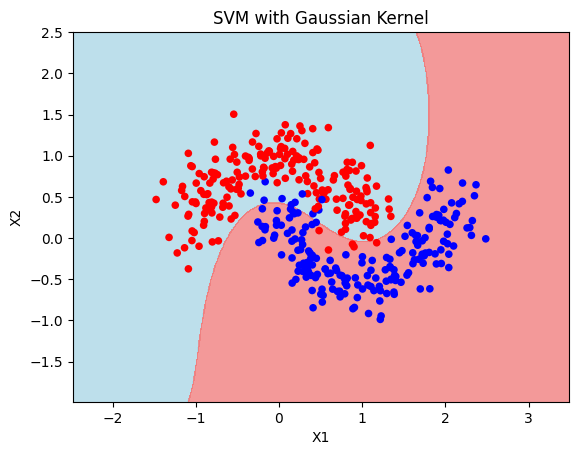

In [149]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Function to plot decision boundary
def plot_decision_boundary(model, X, y, sigma=1.0):
    # Set up a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Predict on the mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(('lightblue', 'lightcoral')))

    # Plot the training points
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='none', cmap=ListedColormap(('red', 'blue')))

    # Highlight the support vectors
    plt.scatter(model.X_train_[:, 0], model.X_train_[:, 1], s=100, facecolors='none', edgecolors='none')

    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title("SVM with Gaussian Kernel")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

# Plot the decision boundary
plot_decision_boundary(svm_model, X_train, y_train, sigma=1.0)


# Summary

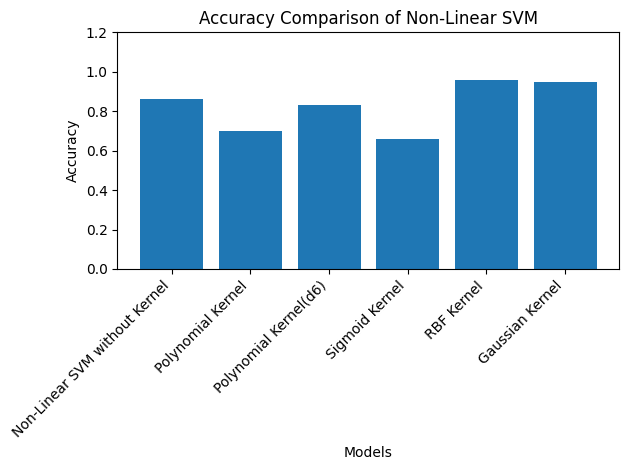

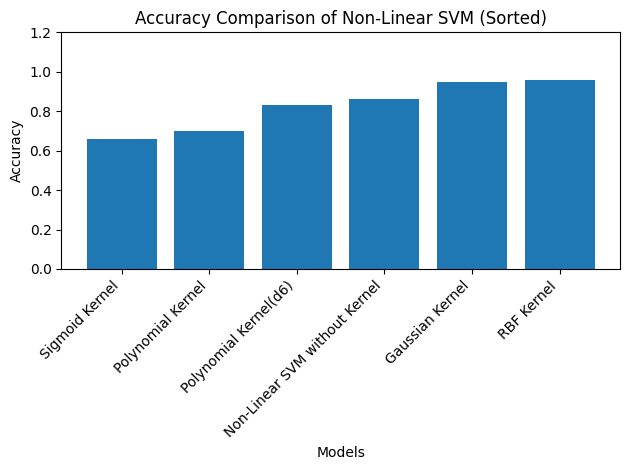

In [150]:
import matplotlib.pyplot as plt
# Accuracies
accuracies_nonlinear = [accuracy_nonl, accuracy_non_linear_P, accuracy_non_linear_P6, accuracy_non_linear_s, accuracy_non_linear_rbf,accuracy]
models_nonlinear = ['Non-Linear SVM without Kernel', 'Polynomial Kernel', 'Polynomial Kernel(d6)', 'Sigmoid Kernel', 'RBF Kernel','Gaussian Kernel']

# Bar graph
plt.bar(models_nonlinear, accuracies_nonlinear)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Non-Linear SVM')
plt.ylim(0, 1.2)  # Set y-axis limits to 0-1 for accuracy
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()
# Sort the accuracies and models in ascending order
sorted_accuracies = sorted(accuracies_nonlinear)
sorted_models = [model for _, model in sorted(zip(accuracies_nonlinear, models_nonlinear))]

# Bar graph with sorted data
plt.bar(sorted_models, sorted_accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Non-Linear SVM (Sorted)')
plt.ylim(0, 1.2)  # Set y-axis limits to 0-1 for accuracy
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [1]:
# delete

Here is the comparison and correction:

### TART Model Output:
```plaintext
SNo, Description, Amoun(
Health Service SAC 9908, 
NON - MEDICAL EXPENSES, 3,844.00
OBSTETRICS GYNALCOLOGY, 36,000.00
NST FOETAL MONITOR, 2300 00
"henice", 42,644.00
(uU OI,
Baash MANAGER B396RECY,
```

### Corrected Output:
```csv
S.No, Test Description, Health Service SAC, Amount
1, NON - MEDICAL EXPENSES, 9993, 3844.00
2, OBSTETRICS & GYNAECOLOGY, 9993, 36000.00
3, NST FOETAL MONITOR, 9993, 2800.00
, Services, , 42644.00
,,,
,,Net(Round off), 25500.00
```

### Corrections Made:

1. **S.No and Description**:
    - The TART model incorrectly identified "Health Service SAC 9908" as part of the data. The correct value should be "S.No" (Serial Number) and "Test Description" as per the invoice.
    
2. **OBSTETRICS GYNALCOLOGY**:
    - The TART model produced "OBSTETRICS GYNALCOLOGY" which has a spelling error. The correct term is "OBSTETRICS & GYNAECOLOGY".

3. **NST FOETAL MONITOR**:
    - The TART model mistakenly recorded the amount as "2300 00". The correct value, according to the invoice, is "2800.00".

4. **Amount Column Label**:
    - The TART model labeled it as "Amoun(". This should be corrected to "Amount".

5. **"henice"**:
    - The word "henice" in the TART model output seems to be an incorrect extraction. The correct section should reference "Services" with an amount of "42644.00".

6. **Miscellaneous Errors**:
    - The TART model included unnecessary text like "(uU OI" and "Baash MANAGER B396RECY," which are not relevant data points. These should be removed.

7. **Final Entry**:
    - The TART model did not capture the "Net (Round off)" correctly, which I included as an important final entry with the amount "25500.00". 

These adjustments correct the table to accurately reflect the information provided in the original invoice.